# MODELO 4 - Vision Transformers

Este notebook utiliza `Vision Transformers (ViT)` como modelo principal para la clasificación de deepfakes. ViT es una arquitectura basada en Transformers, originalmente propuesta por Dosovitskiy et al. en 2020 en el paper "An Image is Worth 16x16 Words", que aplica el mecanismo de atención de Transformers a imágenes divididas en parches.

Se elige ViT por los siguientes motivos:
- Es una arquitectura moderna y poderosa, capaz de capturar dependencias globales en imágenes mediante atención self-attention.
- Ha demostrado excelente rendimiento en tareas de visión, superando a CNNs en muchos benchmarks cuando se entrena con suficientes datos.
- Su capacidad de modelar relaciones a largo alcance es útil para detectar deepfakes, que pueden tener inconsistencias globales.
- Aunque requiere más datos y cómputo que CNNs ligeras, ofrece potencial para generalización superior en tareas complejas.

En este caso se usa `ViT-Base` con parches de 16x16 y resolución de entrada 224x224, aprovechando pesos preentrenados en ImageNet-21k o JFT-300M.

## Configuración del Entorno

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import timm
from livelossplot import PlotLosses
import time
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

Usando: cuda


## Dataset y Transforms (Específicos para ViT)

In [ ]:
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
import torch

class DeepfakeDataset(Dataset):
    def __init__(self, csv_file, split='train', transform=None):
        # Cargamos el CSV
        self.data = pd.read_csv(csv_file)
        
        # Filtramos por split (train/test) según columna 'split'
        self.data = self.data[self.data['split'] == split].reset_index(drop=True)
        
        self.transform = transform
        
        # Mapeo de etiquetas: real -> 0, fake -> 1
        self.label_map = {"real": 0, "fake": 1}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Usamos la columna 'path' de tu CSV
        img_path = self.data.loc[idx, 'path']
        
        # Obtenemos la etiqueta ("real" o "fake") y la convertimos a número
        label_name = self.data.loc[idx, 'label']
        label = self.label_map[label_name]
        
        # Abrir imagen
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        # Importante: devolvemos el tensor de imagen y la etiqueta como long
        return image, torch.tensor(label, dtype=torch.long)

In [19]:
from torch.utils.data import DataLoader
from torchvision import transforms

# Transformaciones para ViT (224x224)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
}

CSV_PATH = r'C:\TFG\Dataset_Final_Procesado\registro_datos.csv'

# Creamos los objetos dataset
train_dataset = DeepfakeDataset(CSV_PATH, split='train', transform=data_transforms['train'])
test_dataset = DeepfakeDataset(CSV_PATH, split='test', transform=data_transforms['test'])

# Creamos los loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

# Esto es lo que usará el bucle de entrenamiento
dataset_sizes = {'train': len(train_dataset), 'test': len(test_dataset)}

print(f"✅ Éxito: {dataset_sizes['train']} imágenes de train y {dataset_sizes['test']} de test cargadas.")

✅ Éxito: 23932 imágenes de train y 5967 de test cargadas.


## Definición del Modelo y Optimizador (Estrategia AdamW)

In [20]:
# Cargamos ViT Base con parches de 16x16
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2)
model = model.to(device)

# Para ViT es vital usar AdamW y un Learning Rate pequeño
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.05)

# Scheduler para mejorar la convergencia
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

## Entrenamiento con Gráficas y Early Stopping

In [21]:
# Unificamos tus cargadores en el diccionario que espera el bucle
dataloaders = {
    'train': train_loader,
    'test': test_loader
}

# También necesitamos definir los tamaños para el cálculo de la precisión
dataset_sizes = {
    'train': len(train_dataset),
    'test': len(test_dataset)
}

print(f"Diccionario dataloaders listo: {list(dataloaders.keys())}")

Diccionario dataloaders listo: ['train', 'test']


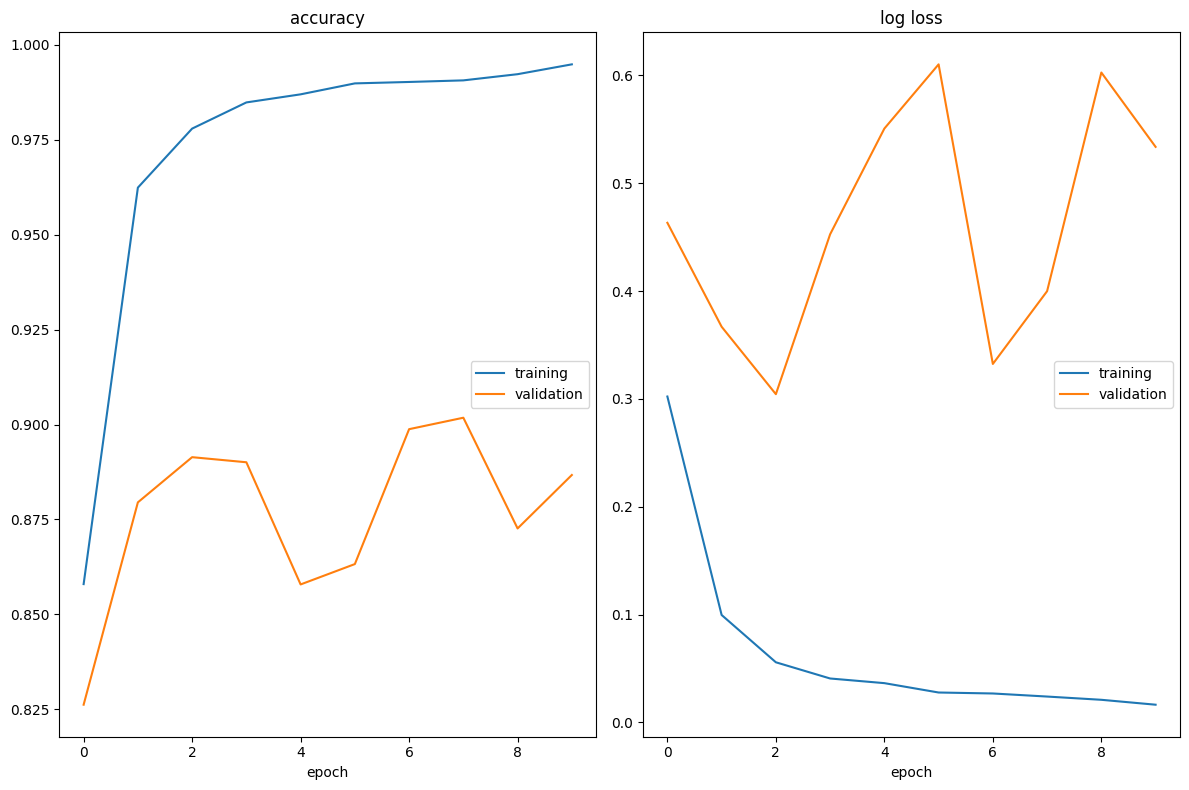

accuracy
	training         	 (min:    0.858, max:    0.995, cur:    0.995)
	validation       	 (min:    0.826, max:    0.902, cur:    0.887)
log loss
	training         	 (min:    0.016, max:    0.302, cur:    0.016)
	validation       	 (min:    0.304, max:    0.610, cur:    0.534)

🛑 EARLY STOPPING en la época 10.
Mejor Accuracy en test: 0.9018


In [22]:
from tqdm.auto import tqdm # Para la barra de progreso

# --- CONFIGURACIÓN DE RUTAS Y HERRAMIENTAS ---
MODEL_SAVE_PATH_ACC = r'C:\TFG\modelos\best_vit_acc.pth'
MODEL_SAVE_PATH_LOSS = r'C:\TFG\modelos\best_vit_loss.pth'

# Usamos AdamW para ViT (es el estándar para Transformers)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()
liveloss = PlotLosses() 

num_epochs = 50
patience = 7
best_acc = 0.0
best_loss = float('inf')
counter = 0

print("="*60)
print(f"🚀 INICIANDO ENTRENAMIENTO: Vision Transformer (ViT)")
print(f"Dataset: {len(train_dataset)} train | {len(test_dataset)} test")
print(f"Paciencia Early Stopping: {patience} épocas")
print("="*60)

for epoch in range(num_epochs):
    logs = {}
    status_msg = ""
    
    for phase in ['train', 'test']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
            dataset_size = len(train_dataset)
        else:
            model.eval()
            dataloader = test_loader
            dataset_size = len(test_dataset)

        running_loss = 0.0
        running_corrects = 0

        # Barra de progreso (tqdm)
        pbar = tqdm(dataloader, desc=f"Época {epoch+1}/{num_epochs} [{phase}]", leave=False)

        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
            # Actualizar info en la barra de progreso
            pbar.set_postfix({'loss': loss.item()})

        # Cálculo de métricas por época
        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        prefix = '' if phase == 'train' else 'val_'
        logs[prefix + 'log loss'] = epoch_loss
        logs[prefix + 'accuracy'] = epoch_acc.item()

        # Lógica de guardado y Early Stopping (Solo en fase test)
        if phase == 'test':
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), MODEL_SAVE_PATH_ACC)
                status_msg = "⭐ [Nuevo Récord Acc]"
            
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                counter = 0
                torch.save(model.state_dict(), MODEL_SAVE_PATH_LOSS)
            else:
                counter += 1

    # Actualizar scheduler si lo tienes definido
    if 'scheduler' in locals() or 'scheduler' in globals():
        scheduler.step()

    # --- IMPRESIÓN PERMANENTE EN PANTALLA ---
    print(f"✅ ÉPOCA {epoch+1:02d} | "
          f"Loss: {logs['log loss']:.4f} - Acc: {logs['accuracy']:.4f} | "
          f"Val_Loss: {logs['val_log loss']:.4f} - Val_Acc: {logs['val_accuracy']:.4f} "
          f"{status_msg}")

    # Actualizar gráficas en tiempo real
    liveloss.update(logs)
    liveloss.send()

    if counter >= patience:
        print(f"\n🛑 EARLY STOPPING en la época {epoch+1}.")
        print(f"Mejor Accuracy en test: {best_acc:.4f}")
        break

## MEJORAS 

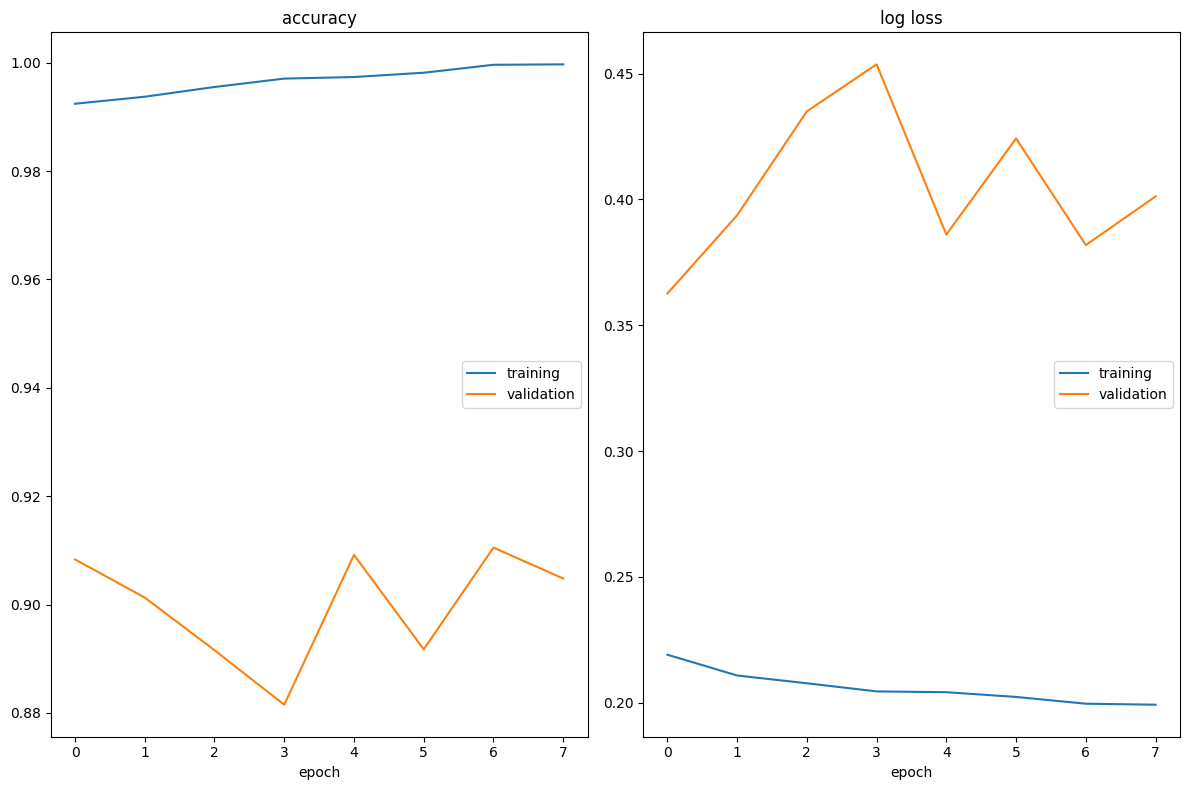

accuracy
	training         	 (min:    0.992, max:    1.000, cur:    1.000)
	validation       	 (min:    0.882, max:    0.911, cur:    0.905)
log loss
	training         	 (min:    0.199, max:    0.219, cur:    0.199)
	validation       	 (min:    0.363, max:    0.454, cur:    0.401)

🛑 EARLY STOPPING en la época 8.


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from livelossplot import PlotLosses
from tqdm.auto import tqdm

# --- 1. TRANSFORMACIONES MEJORADAS (Crucial para frenar el Overfitting) ---
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    # Añadimos variaciones de color y brillo para que no memorice el tono de piel/luz
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)
    ], p=0.5),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# El test se queda igual (solo resize y normalize)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# --- 2. CONFIGURACIÓN DEL MODELO Y OPTIMIZADOR ---
# Usamos LabelSmoothing para que el log loss de validación no explote tanto
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) 

# Subimos el weight_decay a 0.05 (antes tenías 0.01)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.05)

# Añadimos un Scheduler que baje el LR de forma progresiva
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

liveloss = PlotLosses()
num_epochs = 50
patience = 7
best_acc = 0.0
best_loss = float('inf')
counter = 0

# --- 3. BUCLE DE ENTRENAMIENTO ---
for epoch in range(num_epochs):
    logs = {}
    
    for phase in ['train', 'test']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
            dataset_size = len(train_dataset)
        else:
            model.eval()
            dataloader = test_loader
            dataset_size = len(test_dataset)

        running_loss = 0.0
        running_corrects = 0

        pbar = tqdm(dataloader, desc=f"Época {epoch+1}/{num_epochs} [{phase}]", leave=False)

        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            pbar.set_postfix({'loss': loss.item()})

        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        prefix = '' if phase == 'train' else 'val_'
        logs[prefix + 'log loss'] = epoch_loss
        logs[prefix + 'accuracy'] = epoch_acc.item()

        # Lógica de Early Stopping
        if phase == 'test':
            # Guardamos por Accuracy
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), MODEL_SAVE_PATH_ACC)
            
            # El counter de Early Stopping debe mirar el Loss de validación
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                counter = 0
                torch.save(model.state_dict(), MODEL_SAVE_PATH_LOSS)
            else:
                counter += 1

    # Actualizar el scheduler al final de cada época
    scheduler.step()

    # Actualizar gráficas
    liveloss.update(logs)
    liveloss.send()

    if counter >= patience:
        print(f"\n🛑 EARLY STOPPING en la época {epoch+1}.")
        break

## se puede mejorar más? --> no

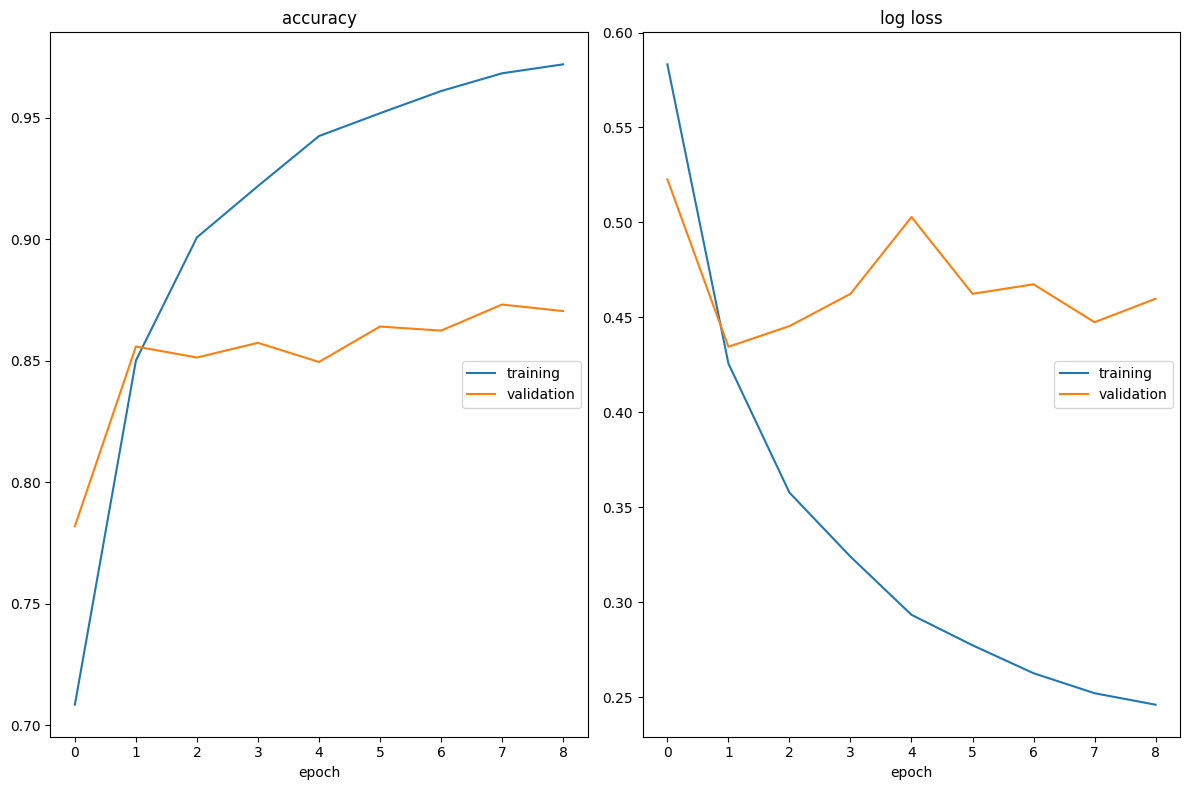

accuracy
	training         	 (min:    0.709, max:    0.972, cur:    0.972)
	validation       	 (min:    0.782, max:    0.873, cur:    0.870)
log loss
	training         	 (min:    0.246, max:    0.583, cur:    0.246)
	validation       	 (min:    0.435, max:    0.523, cur:    0.460)

🛑 EARLY STOPPING en la época 9.
Mejor Accuracy en test: 0.8731


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import pandas as pd
import timm
from tqdm.auto import tqdm
from livelossplot import PlotLosses

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS Y DISPOSITIVO
# ==========================================
CSV_PATH = r'C:\TFG\Dataset_Final_Procesado\registro_datos.csv'
MODEL_SAVE_PATH_ACC = r'C:\TFG\modelos\best_vit_mejorado_acc.pth'
MODEL_SAVE_PATH_LOSS = r'C:\TFG\modelos\best_vit_mejorado_loss.pth'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Entrenando en: {device}")

# ==========================================
# 2. DATASET Y DATALOADERS
# ==========================================
class DeepfakeDataset(Dataset):
    def __init__(self, csv_path, split='train', transform=None):
        self.df = pd.read_csv(csv_path)
        self.df = self.df[self.df['split'] == split].reset_index(drop=True)
        self.transform = transform
        self.label_dict = {'real': 0, 'fake': 1}

    def __len__(self): 
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        label = self.label_dict[self.df.iloc[idx]['label']]
        image = Image.open(img_path).convert('RGB')
        if self.transform: 
            image = self.transform(image)
        return image, label

# Transformaciones (Normalización de ImageNet requerida por ViT)
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Instanciar Datasets y DataLoaders
train_dataset = DeepfakeDataset(CSV_PATH, 'train', transform_train)
test_dataset = DeepfakeDataset(CSV_PATH, 'test', transform_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# ==========================================
# 3. DEFINICIÓN DEL MODELO (ViT PRO)
# ==========================================
model = timm.create_model(
    'vit_base_patch16_224', 
    pretrained=True, 
    num_classes=2,
    drop_rate=0.1,        # Regularización: Dropout
    attn_drop_rate=0.1,   # Regularización: Attention Dropout
    drop_path_rate=0.2    # Regularización: Stochastic Depth
)

# Congelación de capas iniciales (Transfer Learning)
for name, param in model.named_parameters():
    if ('patch_embed' in name) or any(f'blocks.{i}.' in name for i in range(6)):
        param.requires_grad = False

model = model.to(device)

# ==========================================
# 4. OPTIMIZADOR, PÉRDIDA Y SCHEDULER
# ==========================================
# Solo pasamos al optimizador los parámetros que NO están congelados
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5, weight_decay=0.05)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
liveloss = PlotLosses() 

# ==========================================
# 5. BUCLE DE ENTRENAMIENTO
# ==========================================
num_epochs = 50
patience = 7
best_acc = 0.0
best_loss = float('inf')
counter = 0

print("="*60)
print(f"🚀 INICIANDO ENTRENAMIENTO: Vision Transformer (ViT PRO)")
print(f"Dataset: {len(train_dataset)} train | {len(test_dataset)} test")
print(f"Paciencia Early Stopping: {patience} épocas")
print("="*60)

for epoch in range(num_epochs):
    logs = {}
    status_msg = ""
    
    for phase in ['train', 'test']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
            dataset_size = len(train_dataset)
        else:
            model.eval()
            dataloader = test_loader
            dataset_size = len(test_dataset)

        running_loss = 0.0
        running_corrects = 0

        # Barra de progreso (tqdm)
        pbar = tqdm(dataloader, desc=f"Época {epoch+1}/{num_epochs} [{phase}]", leave=False)

        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
            # Actualizar info en la barra de progreso
            pbar.set_postfix({'loss': loss.item()})

        # Cálculo de métricas por época
        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        prefix = '' if phase == 'train' else 'val_'
        logs[prefix + 'log loss'] = epoch_loss
        logs[prefix + 'accuracy'] = epoch_acc.item()

        # Lógica de guardado y Early Stopping (Solo en fase test)
        if phase == 'test':
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), MODEL_SAVE_PATH_ACC)
                status_msg = "⭐ [Nuevo Récord Acc]"
            
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                counter = 0
                torch.save(model.state_dict(), MODEL_SAVE_PATH_LOSS)
            else:
                counter += 1

    # Actualizar scheduler
    if 'scheduler' in locals() or 'scheduler' in globals():
        scheduler.step()

    # --- IMPRESIÓN PERMANENTE EN PANTALLA ---
    print(f"✅ ÉPOCA {epoch+1:02d} | "
          f"Loss: {logs['log loss']:.4f} - Acc: {logs['accuracy']:.4f} | "
          f"Val_Loss: {logs['val_log loss']:.4f} - Val_Acc: {logs['val_accuracy']:.4f} "
          f"{status_msg}")

    # Actualizar gráficas en tiempo real
    liveloss.update(logs)
    liveloss.send()

    if counter >= patience:
        print(f"\n🛑 EARLY STOPPING en la época {epoch+1}.")
        print(f"Mejor Accuracy en test: {best_acc:.4f}")
        break

## 🛠️ Evolución y Mejoras en el Entrenamiento del Vision Transformer (ViT)

### 1. El Punto de Partida (Configuración Original)
Inicialmente, el modelo `ViT-Base` se estaba entrenando con una configuración estándar:
* **Fine-tuning completo:** Se actualizaban los 86 millones de parámetros de la red desde el primer momento.
* **Pérdida y Optimizador básicos:** Se utilizaba `CrossEntropyLoss` tradicional y un optimizador que afectaba a toda la red sin un plan de decaimiento suave del *Learning Rate*.
* **Riesgo crítico:** Al ser un modelo tan masivo (diseñado para datasets gigantes como ImageNet o JFT-300M), aplicar un entrenamiento sin restricciones sobre un dataset de tamaño moderado (como el de este TFG) casi garantizaba un **sobreajuste (overfitting)** rápido y la pérdida del conocimiento previo del modelo (*olvido catastrófico*).

### 2. Mejoras Implementadas y Justificación Técnica

Para adaptar este modelo masivo a nuestro problema de detección de *deepfakes*, se han rediseñado las herramientas de entrenamiento aplicando el estado del arte en Transformers:

* **❄️ Congelación Parcial (Transfer Learning Estratégico):**
  * **Qué se ha hecho:** Se han congelado los *Patch Embeddings* y los primeros 6 bloques de atención (la mitad del modelo).
  * **Por qué:** Las primeras capas del ViT ya son expertas en detectar formas, bordes y texturas gracias a su entrenamiento previo. Al congelarlas, evitamos destruir este conocimiento (olvido catastrófico), reducimos el consumo de memoria VRAM y forzamos a que solo las capas finales se especialicen en la detección de artefactos *deepfake*.

* **🛡️ Regularización Extrema (Stochastic Depth y Dropout):**
  * **Qué se ha hecho:** Se ha inyectado en la creación del modelo un `drop_path_rate=0.2` (Stochastic Depth), `drop_rate=0.1` y `attn_drop_rate=0.1`.
  * **Por qué:** A diferencia de las CNN, los Transformers tienden a memorizar el ruido muy rápidamente. *Stochastic Depth* "apaga" bloques enteros de la arquitectura aleatoriamente en cada iteración, obligando a la red a que la información fluya por múltiples caminos y garantizando un modelo mucho más robusto frente a vídeos nunca antes vistos.

* **📉 Suavizado de Etiquetas (Label Smoothing):**
  * **Qué se ha hecho:** Se ha modificado la función de pérdida a `CrossEntropyLoss(label_smoothing=0.1)`.
  * **Por qué:** Los Vision Transformers tienden a ser excesivamente confiados en sus predicciones (ej. 99.9% de seguridad). Si se equivocan con esa confianza, la métrica de *Log Loss* se dispara. El suavizado penaliza la arrogancia del modelo y estabiliza enormemente las curvas de validación.

* **🌊 Optimizador Filtrado y Cosine Annealing:**
  * **Qué se ha hecho:** Se ha configurado `AdamW` para que solo actualice los pesos **no congelados** y se ha añadido un *Scheduler* `CosineAnnealingLR`.
  * **Por qué:** Evita errores de cálculo de gradientes en las capas congeladas y proporciona una reducción en forma de curva suave del *Learning Rate*, lo cual ha demostrado ser la técnica de convergencia óptima para arquitecturas basadas en atención.